In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Carregando direto da internet
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nPrimeiras linhas:")
df.head()

Shape: (891, 12)

Primeiras linhas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Verificando nulos
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
# Estatísticas gerais
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [12]:
# Quantos sobreviveram?
print(df["Survived"].value_counts())
print(f"\nTaxa de sobrevivência: {df['Survived'].mean()*100:.1f}%")

Survived
0    549
1    342
Name: count, dtype: int64

Taxa de sobrevivência: 38.4%


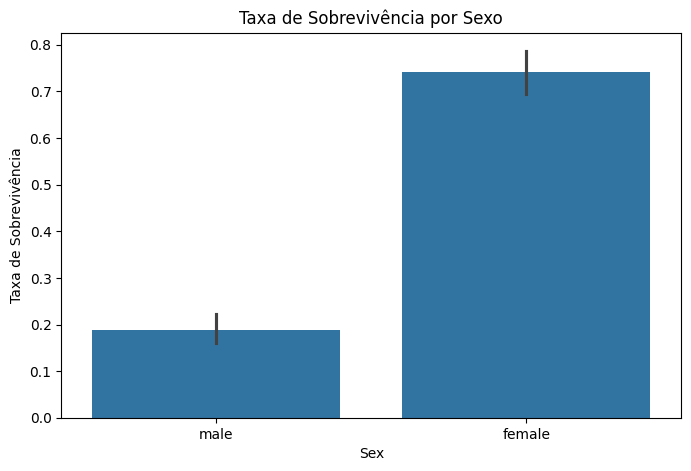

In [13]:
# 1. Taxa de sobrevivência por sexo
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Taxa de Sobrevivência por Sexo")
plt.ylabel("Taxa de Sobrevivência")
plt.show()

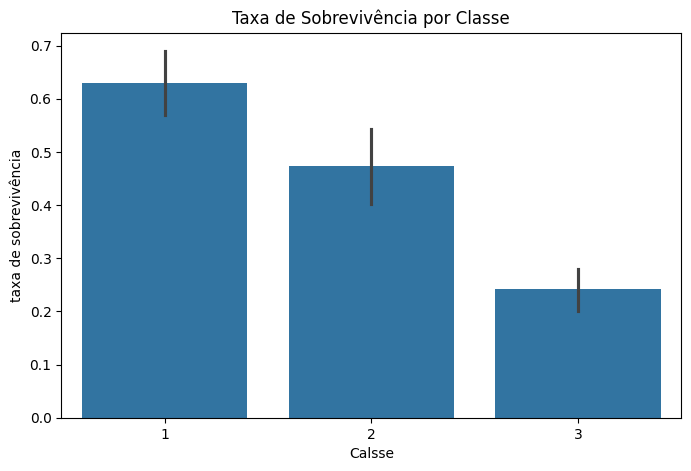

In [14]:
# 2. Taxa de sobrevivência por classe
plt.figure(figsize=(8,5 ))
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Taxa de Sobrevivência por Classe")
plt.xlabel("Calsse")
plt.ylabel("taxa de sobrevivência")
plt.show()

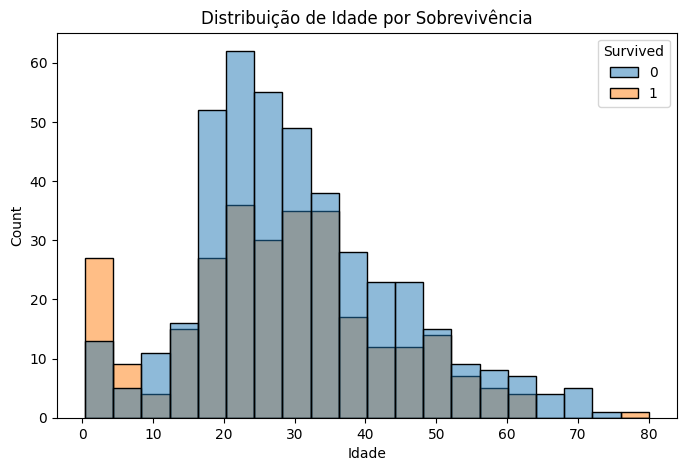

In [15]:
# 3. Distribuição de idade por sobrevivência
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Survived", bins=20)
plt.title("Distribuição de Idade por Sobrevivência")
plt.xlabel("Idade")
plt.show()

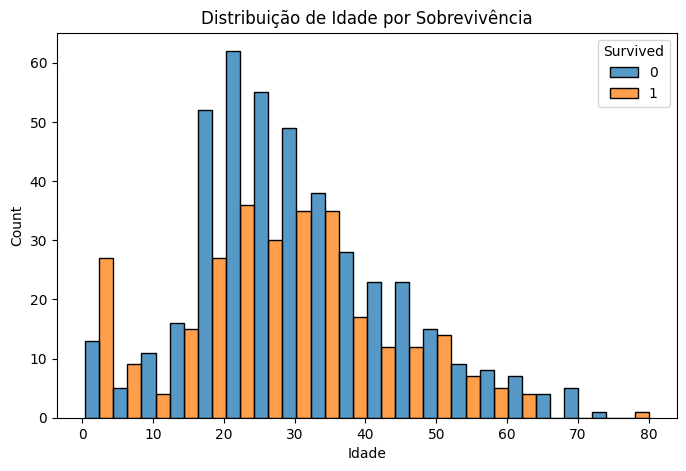

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", bins=20, multiple="dodge")
plt.title("Distribuição de Idade por Sobrevivência")
plt.xlabel("Idade")
plt.show()

In [17]:
# 1. Removendo colunas inúteis para o modelo
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# 2. Preenchendo nulos
df["Age"] = df['Age'].fillna(df['Age'].median())
df["Embarked"] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Convertendo texto para número
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

print(df.head())
print("\nNulos restantes:")
print(df.isnull().sum())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True

Nulos restantes:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [18]:
# Separando X e y
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinando
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Prevendo
y_pred = modelo.predict(X_test)

# Avaliando
print(f"Acurácia: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nRelatório completo:")
print(classification_report(y_test, y_pred))


Acurácia: 81.0%

Relatório completo:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



     variavel  coeficiente
1         Sex     2.591222
5        Fare     0.002576
2         Age    -0.030574
4       Parch    -0.107848
6  Embarked_Q    -0.111981
3       SibSp    -0.295062
7  Embarked_S    -0.400561
0      Pclass    -0.938047


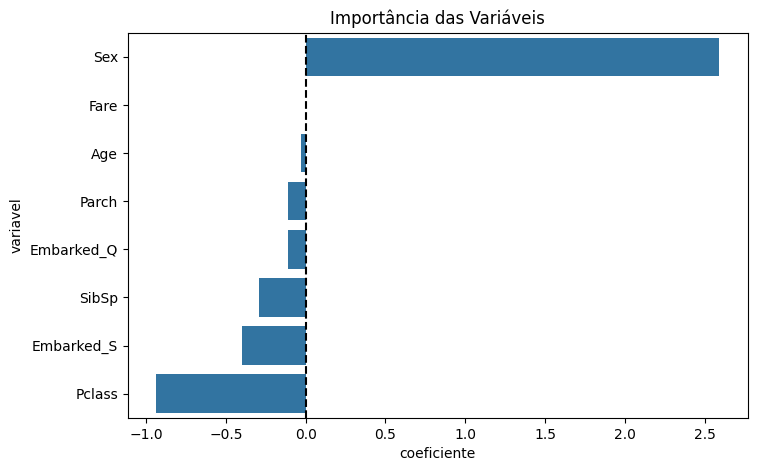

In [19]:
# Quais variáveis mais influenciaram o modelo?
importancia = pd.DataFrame({
    "variavel": X.columns,
    "coeficiente": modelo.coef_[0]
}).sort_values("coeficiente", ascending=False)

print(importancia)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancia, x="coeficiente", y="variavel")
plt.title("Importância das Variáveis")
plt.axvline(x=0, color="black", linestyle="--")
plt.show()


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

print("Bibliotecas carregadas!")


Bibliotecas carregadas!


In [21]:
# Regressão Logística (já temos, só guardando o resultado)
acc_lr = accuracy_score(y_test, y_pred)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

# Comparando
print(f"Regressão Logística: {acc_lr*100:.1f}%")
print(f"Random Forest:       {acc_rf*100:.1f}%")
print(f"XGBoost:             {acc_xgb*100:.1f}%")

Regressão Logística: 81.0%
Random Forest:       79.9%
XGBoost:             80.4%


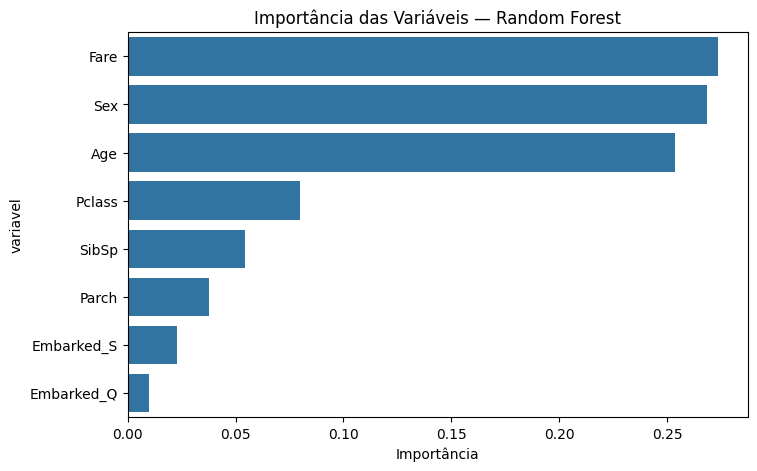

In [22]:
# Importância das variáveis no Random Forest
importancia_rf = pd.DataFrame({
    "variavel": X.columns,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancia_rf, x="importancia", y="variavel")
plt.title("Importância das Variáveis — Random Forest")
plt.xlabel("Importância")
plt.show()

In [23]:
# Testando diferentes configurações
configs = [
    {"n_estimators": 50,  "max_depth": 3},
    {"n_estimators": 100, "max_depth": 5},
    {"n_estimators": 200, "max_depth": 7},
    {"n_estimators": 200, "max_depth": None},
]

for config in configs:
    rf_teste = RandomForestClassifier(random_state=42, **config)
    rf_teste.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf_teste.predict(X_test))
    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']} → {acc*100:.1f}%")


n_estimators=50, max_depth=3 → 80.4%
n_estimators=100, max_depth=5 → 81.6%
n_estimators=200, max_depth=7 → 81.6%
n_estimators=200, max_depth=None → 81.0%


In [24]:
configs_xgb = [
    {"n_estimators": 50,  "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 100, "max_depth": 4, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
]

for config in configs_xgb:
    xgb_teste = xgb.XGBClassifier(random_state=42, eval_metric="logloss", **config)
    xgb_teste.fit(X_train, y_train)
    acc = accuracy_score(y_test, xgb_teste.predict(X_test))
    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']}, learning_rate={config['learning_rate']} → {acc*100:.1f}%")

n_estimators=50, max_depth=3, learning_rate=0.1 → 82.1%
n_estimators=100, max_depth=4, learning_rate=0.1 → 80.4%
n_estimators=200, max_depth=3, learning_rate=0.05 → 82.1%
